# Importar librerías

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
import warnings
warnings.filterwarnings("ignore")   

# EDA

Los Datos fueron generados a través de un sistema de simulación, automatizado para que el código quede mas limpio. Para más información revisar `data-science\src\generar_dataset_perfiles.py`

In [3]:
df = pd.read_csv("../data/raw/perfiles_simulados.csv")
df

,Ingreso_Mensual,Proporcion_Gasto,Gasto_Total,Nivel_Endeudamiento,Frecuencia_Ahorro,Perfil_Financiero
0,20968.73,86.58,18154.54,37.45,Media,Saludable
1,109240.09,42.20,46102.73,95.07,Baja,En Riesgo
2,65370.96,76.10,49749.30,73.20,Baja,En Riesgo
3,100837.78,78.54,79195.17,59.87,Baja,En Riesgo
4,44921.24,63.93,28718.35,15.60,Media,Saludable
...,...,...,...,...,...,...
395,105880.18,99.72,105586.83,93.08,Media,En Riesgo
396,112504.64,107.88,121369.01,85.84,Baja,En Riesgo
397,71982.88,107.51,77388.95,42.90,Baja,En Riesgo
398,86504.79,89.97,77830.22,75.09,Baja,En Riesgo


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Ingreso_Mensual      400 non-null    float64
 1   Proporcion_Gasto     400 non-null    float64
 2   Gasto_Total          400 non-null    float64
 3   Nivel_Endeudamiento  400 non-null    float64
 4   Frecuencia_Ahorro    400 non-null    object 
 5   Perfil_Financiero    400 non-null    object 
dtypes: float64(4), object(2)
memory usage: 18.9+ KB


In [5]:
print(f"Datos únicos: {df.count().unique()}\n")
print(f"Tipo de datos: \n{df.dtypes}\n")
print(f"Datos nulos: \n{df.count().isnull()}\n")

df.describe()

Datos únicos: [400]

Tipo de datos: 
Ingreso_Mensual        float64
Proporcion_Gasto       float64
Gasto_Total            float64
Nivel_Endeudamiento    float64
Frecuencia_Ahorro       object
Perfil_Financiero       object
dtype: object

Datos nulos: 
Ingreso_Mensual        False
Proporcion_Gasto       False
Gasto_Total            False
Nivel_Endeudamiento    False
Frecuencia_Ahorro      False
Perfil_Financiero      False
dtype: bool



,Ingreso_Mensual,Proporcion_Gasto,Gasto_Total,Nivel_Endeudamiento
count,400.000000,400.000000,400.000000,400.000000
mean,64760.300525,70.284300,45894.790700,49.419250
std,32440.720735,23.746632,29548.280598,29.375659
min,10778.670000,30.370000,3567.530000,0.510000
25%,36285.900000,48.612500,22008.152500,24.132500
50%,65129.855000,71.510000,38142.905000,51.170000
75%,93560.250000,91.162500,63986.050000,74.752500
max,119968.830000,109.830000,130098.750000,99.050000


# Ingeniería de atributos

In [6]:
df["ratio_gasto_ingreso"] = df["Gasto_Total"] / df["Ingreso_Mensual"]
df["ratio_gasto_ingreso"]

0      0.865791
1      0.422031
2      0.761031
3      0.785372
4      0.639304
         ...   
395    0.997229
396    1.078791
397    1.075102
398    0.899722
399    0.404069
Name: ratio_gasto_ingreso, Length: 400, dtype: float64

Ordinal Encoding para `frecuencia_ahorro`, ya que `Baja<Media<Alta` tiene un orden lógico


In [7]:
ordinal_encoder = OrdinalEncoder(categories=[["Baja", "Media", "Alta"]])
df["frecuencia_ahorro_encoded"] = ordinal_encoder.fit_transform(
    df[["Frecuencia_Ahorro"]]
)
df["frecuencia_ahorro_encoded"]

0      1.0
1      0.0
2      0.0
3      0.0
4      1.0
      ... 
395    1.0
396    0.0
397    0.0
398    0.0
399    2.0
Name: frecuencia_ahorro_encoded, Length: 400, dtype: float64

# Visualizaciones

#### Conteo de Perfiles Financieros

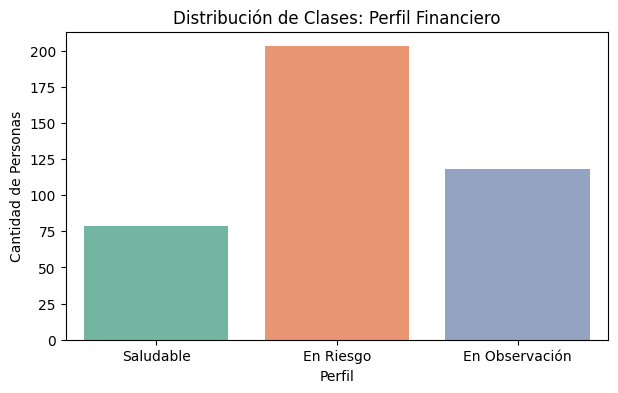

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Perfil_Financiero", palette="Set2")
plt.title("Distribución de Clases: Perfil Financiero")
plt.xlabel("Perfil")
plt.ylabel("Cantidad de Personas")
plt.show()

#### Diagrama de Dispersión: Endeudamiento vs Ratio Gasto/Ingreso

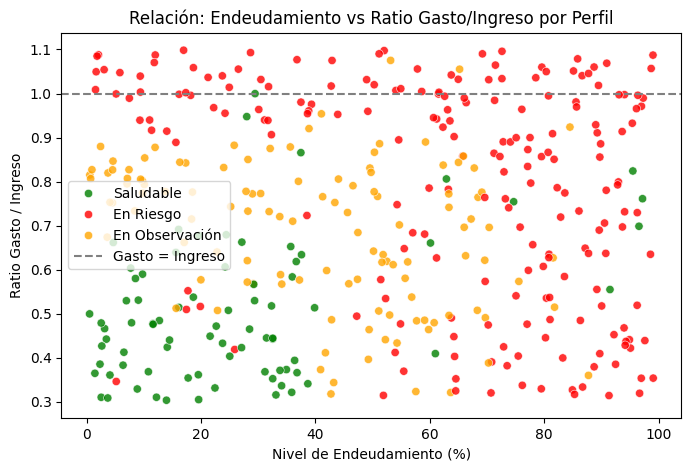

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Nivel_Endeudamiento",
    y="ratio_gasto_ingreso",
    hue="Perfil_Financiero",
    palette={"Saludable": "green", "En Observación": "orange", "En Riesgo": "red"},
    alpha=0.8,
)
plt.title("Relación: Endeudamiento vs Ratio Gasto/Ingreso por Perfil")
plt.xlabel("Nivel de Endeudamiento (%)")
plt.ylabel("Ratio Gasto / Ingreso")
plt.axhline(1.0, color="gray", linestyle="--", label="Gasto = Ingreso")
plt.legend()
plt.show()

#### Matriz de Correlación

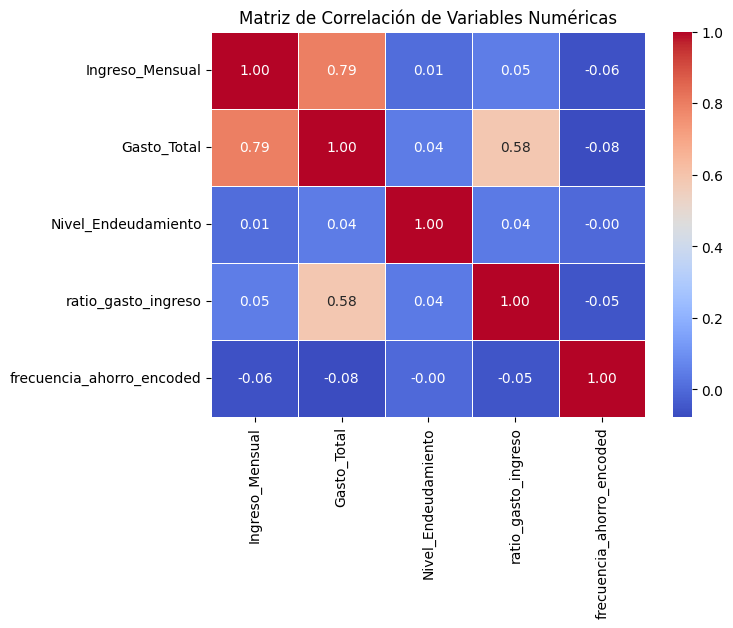

In [10]:
plt.figure(figsize=(7, 5))
numeric_cols = [
    "Ingreso_Mensual",
    "Gasto_Total",
    "Nivel_Endeudamiento",
    "ratio_gasto_ingreso",
    "frecuencia_ahorro_encoded",
]
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

#### Distribución de Frecuencia de Ahorro según Perfil

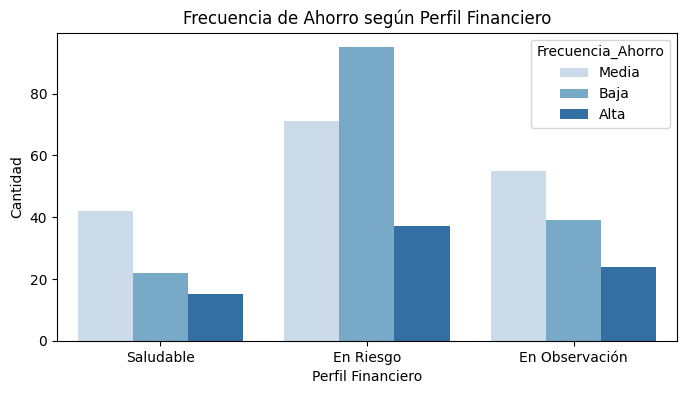

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Perfil_Financiero", hue="Frecuencia_Ahorro", palette="Blues")
plt.title("Frecuencia de Ahorro según Perfil Financiero")
plt.xlabel("Perfil Financiero")
plt.ylabel("Cantidad")
plt.show()

# Guarda el `CSV` procesado

In [12]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "perfiles_procesados.csv"

df.to_csv(output_path, sep=",", encoding="utf-8", index=False)

# Modelo de perfil financiero

Escala las variables numéricas con `StandardScaler` para poder usar `LogisticRegression`, `RandomForestClassifier` y `DecisionTreeClassifier` para la clasificación y comparar cuál es mejor

In [13]:
features = [
    "Ingreso_Mensual",
    "Nivel_Endeudamiento",
    "ratio_gasto_ingreso",
    "frecuencia_ahorro_encoded",
]

X = df[features]
y = df["Perfil_Financiero"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Logistic Regression Model ---
model_logreg = LogisticRegression(random_state=42)
model_logreg.fit(X_train_scaled, y_train)

y_pred_logreg = model_logreg.predict(X_test_scaled)

# --- Random Forest Classifier ---
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

# --- Decision Tree Classifier ---
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_scaled, y_train)

y_pred_dt = model_dt.predict(X_test_scaled)